In [1]:
import torch
import warnings
import sys
import os
import math
warnings.filterwarnings("ignore")
# allows us to import from the custom configs directory w/o affecting deepdisc library imports
sys.path.insert(0, '/u/yse2/deepdisc/configs')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from deepdisc.data_format.register_data import register_data_set
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.config import LazyConfig, instantiate
from detectron2.checkpoint import DetectionCheckpointer
from detectron2.modeling.proposal_generator.proposal_utils import add_ground_truth_to_proposals
from detectron2.modeling.roi_heads import select_foreground_proposals
from detectron2.utils.events import EventStorage

from deepdisc.model.loaders import return_train_loader
from custom.mappers import FileNameWCSMapper, CLIPMapper

from deepdisc.utils.norms import asinh_norm
from astropy.visualization import make_lupton_rgb
from deepdisc.astrodet.visualizer import Visualizer, ColorMode
from detectron2.structures import Instances, pairwise_iou

In [2]:
data_root_dir = os.path.expanduser('~/lsst_data/')
anns_folder = 'annotations_lvl5'
class CLIPFnWCSMapper(CLIPMapper):
    """
    Data mapper for CLIP Training Mapper
    This mapper builds on top of CLIPMapper and returns file names and WCS info as well
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
    
    def map_data(self, dataset_dict):
        # calling the map_data method from the parent class (CLIPMapper) 
        # This will do all the image loading, augmentations, and instance transformations
        d = super().map_data(dataset_dict)
        d['file_name'] = dataset_dict['file_name']
        d['wcs'] = dataset_dict['wcs']
        return d

MAPPER_REGISTRY = {
    "standard_30k": FileNameWCSMapper,
    "standard_all": FileNameWCSMapper,
    "clip_30k": CLIPFnWCSMapper,
    "clip_all": CLIPFnWCSMapper,
}
MODEL_DEFAULTS = {
    "standard_30k": {
        "cfgfile":      "/u/yse2/deepdisc/configs/solo/swin_lsst_30k.py",
        "run_name":     "lsst5_30k_4h200_bs192_ep50",
        "eval_data_fn": f"{data_root_dir}{anns_folder}/val_4k_keypoints.json",
        "test_data_fn": f"{data_root_dir}{anns_folder}/test_8k_keypoints.json",
    },
    "standard_all": {
        "cfgfile":      "/u/yse2/deepdisc/configs/solo/swin_lsst_100k.py",
        "run_name":     "lsst5_all_4h200_bs192_ep20",
        "eval_data_fn": f"{data_root_dir}{anns_folder}/val_keypoints.json",
        "test_data_fn": f"{data_root_dir}{anns_folder}/test_keypoints.json",
    },
    "clip_30k": {
        "cfgfile":      "/u/yse2/deepdisc/configs/solo/swin_clip_lsst_roman_30k.py",
        "run_name":     "clip5_30k_4h200_bs64_ep50",
        "eval_data_fn": f"{data_root_dir}{anns_folder}/val_4k_keypoints.json",
        "test_data_fn": f"{data_root_dir}{anns_folder}/test_8k_keypoints.json",
    },
    "clip_all": {
        "cfgfile":      "/u/yse2/deepdisc/configs/solo/swin_clip_lsst_roman_100k.py",
        "run_name":     "clip5_all_4h200_bs64_ep20",
        "eval_data_fn": f"{data_root_dir}{anns_folder}/val_keypoints.json",
        "test_data_fn": f"{data_root_dir}{anns_folder}/test_keypoints.json",
    },
}

In [3]:
model_type = "clip_30k" # options: standard_30k, standard_all, clip_30k, clip_all
defaults = MODEL_DEFAULTS[model_type]
cfgfile = None
run_name = None
test_data_fn = None
data_split = 'eval'
if cfgfile is None:
    cfgfile = defaults["cfgfile"]
if run_name is None:
    run_name = defaults["run_name"]
if test_data_fn is None:
    if data_split == 'eval':
        test_data_fn = defaults["eval_data_fn"]
    else:
        test_data_fn = defaults["test_data_fn"]
base_run_dir = os.path.expanduser('~/lsst_runs/')
run_dir = f'{base_run_dir}{run_name}'
# model_path = f'{run_dir}/{run_name}.pth'
model_path = f"/projects/bdsp/yse2/cascade_mask_rcnn_swin_b_in21k_clip_roman_rubin_model.pkl"
print(f"Using config file {cfgfile}")
print(f"Using model from {model_path}")
print(f"Using data from {test_data_fn}")

Using config file /u/yse2/deepdisc/configs/solo/swin_clip_lsst_roman_30k.py
Using model from /projects/bdsp/yse2/cascade_mask_rcnn_swin_b_in21k_clip_roman_rubin_model.pkl
Using data from /u/yse2/lsst_data/annotations_lvl5/val_4k_keypoints.json


In [4]:
test_data = pd.read_json(test_data_fn)
print(f"Loaded data from {test_data_fn} with {len(test_data)} images.")
cfg = LazyConfig.load(cfgfile) # using a Swin Transformer
for key in cfg.get("MISC", dict()).keys():
    cfg[key] = cfg.MISC[key]
cfg.DATASETS.TRAIN = "test_prop"
cfg.dataloader.train.total_batch_size = 16
cfg.SOLVER.IMS_PER_BATCH = 16
cfg.train.init_checkpoint = model_path
print(f"Config loaded successfully!")
print(f"Registering eval dataset from: {test_data_fn}")
try:
    DatasetCatalog.remove(cfg.DATASETS.TRAIN)
    MetadataCatalog.remove(cfg.DATASETS.TRAIN)
except:
    pass
custom_colors = [
    (0, 255, 0),    # green for galaxies
    (0, 0, 255),    # blue for stars
]
astrotest_metadata = register_data_set(
    cfg.DATASETS.TRAIN, test_data_fn, thing_classes=cfg.metadata.classes, thing_colors=custom_colors
)
print(f"Batch size (across all GPUs): {cfg.dataloader.train.total_batch_size}")
print(f"Steps per epoch: {cfg.dataloader.steps_per_epoch}")
print(f"Pixel mean: {cfg.model.rubin_pixel_mean[:3]}...")
print(f"Pixel std: {cfg.model.rubin_pixel_std[:3]}...")  

Loaded data from /u/yse2/lsst_data/annotations_lvl5/val_4k_keypoints.json with 4285 images.
Config loaded successfully!
Registering eval dataset from: /u/yse2/lsst_data/annotations_lvl5/val_4k_keypoints.json
Batch size (across all GPUs): 16
Steps per epoch: 468
Pixel mean: [0.05976027995347977, 0.056569650769233704, 0.0808037668466568]...
Pixel std: [1.0054351091384888, 0.7062947750091553, 1.0013556480407715]...


In [5]:
if "clip" in model_type:
    print("Using CLIP mapper...")
    imagereader = cfg.dataloader.train.imagereader # DualRomanRubinImageReader()
else:
    imagereader = cfg.dataloader.imagereader
    
print("Creating dataloader...")
cfg.dataloader.train.mapper = MAPPER_REGISTRY[model_type]
mapper = cfg.dataloader.train.mapper(
    imagereader, cfg.dataloader.key_mapper, cfg.dataloader.augs, keypoint_hflip_indices=[0]
).map_data
loader = return_train_loader(cfg, mapper)
# persistent iterator from loader so we can call next() multiple times 
# and get different batches
loader_iter = iter(loader)
print(f"Dataloader created successfully!")

Using CLIP mapper...
Creating dataloader...
[03/25 10:27:41 d2.data.build]: Removed 0 images with no usable annotations. 4285 images left.
[03/25 10:27:41 d2.data.build]: Distribution of instances among all 2 categories:
|  category  | #instances   |  category  | #instances   |
|:----------:|:-------------|:----------:|:-------------|
|   galaxy   | 124478       |    star    | 2986         |
|            |              |            |              |
|   total    | 127464       |            |              |
[03/25 10:27:41 d2.data.build]: Using training sampler TrainingSampler
[03/25 10:27:41 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[03/25 10:27:41 d2.data.common]: Serializing 4285 elements to byte tensors and concatenating them all ...
[03/25 10:27:42 d2.data.common]: Serialized dataset takes 48.32 MiB
[03/25 10:27:42 d2.data.build]: Making batched data loader with batch_size=16
Dataloader created successfully!


In [6]:
model = instantiate(cfg.model)
checkpointer = DetectionCheckpointer(model)
checkpointer.load(cfg.train.init_checkpoint)
model.train()
print(f"Model loaded in training mode")

Aligning feature names: ['p3', 'p4', 'p5', 'p6', 'p7'] --> ['p2', 'p3', 'p4', 'p5', 'p6']
Patch size ratio (key/query): 3.25
Final aligned features - Query: ['p2', 'p3', 'p4', 'p5', 'p6'], Key: ['p2', 'p3', 'p4', 'p5', 'p6']
[03/25 10:27:58 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /projects/bdsp/yse2/cascade_mask_rcnn_swin_b_in21k_clip_roman_rubin_model.pkl ...


Skip loading parameter 'backbone_q.bottom_up.patch_embed.proj.weight' to the model due to incompatible shapes: (128, 3, 4, 4) in the checkpoint but (128, 6, 4, 4) in the model! You might want to double check if this is expected.
Skip loading parameter 'backbone_k.bottom_up.patch_embed.proj.weight' to the model due to incompatible shapes: (128, 3, 4, 4) in the checkpoint but (128, 3, 13, 13) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.0.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (3, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.0.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (3,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.1.cls_score.weight' to the model due to incompatible shapes: (81, 10

Model loaded in training mode


In [7]:
# rerun to get a new batch
batch = next(loader_iter)
print(f"Successfully got batch with {len(batch)} samples")

Successfully got batch with 16 samples


In [10]:
for i, b in enumerate(batch):
    print(f"Image {i}: rubin shape={b['image_rubin'].shape}, "
          f"num instances={len(b['instances'])}, "
          f"gt_objid present={b['instances'].has('gt_objid')}, "
          f"file_name={b['file_name']}")

Image 0: rubin shape=torch.Size([6, 149, 148]), num instances=37, gt_objid present=True, file_name=/u/yse2/lsst_data/truth/53.39_-39.3/c215_53.39_-39.3.npy
Image 1: rubin shape=torch.Size([6, 149, 149]), num instances=32, gt_objid present=True, file_name=/u/yse2/lsst_data/truth/51.97_-41.0/c132_51.97_-41.0.npy
Image 2: rubin shape=torch.Size([6, 145, 143]), num instances=31, gt_objid present=True, file_name=/u/yse2/lsst_data/truth/52.70_-40.3/c123_52.70_-40.3.npy
Image 3: rubin shape=torch.Size([6, 149, 148]), num instances=34, gt_objid present=True, file_name=/u/yse2/lsst_data/truth/54.04_-41.5/c60_54.04_-41.5.npy
Image 4: rubin shape=torch.Size([6, 149, 148]), num instances=32, gt_objid present=True, file_name=/u/yse2/lsst_data/truth/51.39_-40.3/c45_51.39_-40.3.npy
Image 5: rubin shape=torch.Size([6, 149, 148]), num instances=40, gt_objid present=True, file_name=/u/yse2/lsst_data/truth/51.72_-40.3/c197_51.72_-40.3.npy
Image 6: rubin shape=torch.Size([6, 148, 145]), num instances=25, 

In [ ]:
with EventStorage():
    with torch.no_grad():
        images_q_rubin = model.preprocess_image(batch, "image_rubin", model.rubin_pixel_mean, 
                                                model.rubin_pixel_std, model.backbone_q.size_divisibility, 
                                                model.backbone_q.padding_constraints)
        # for first run we use all instances (100% labeled data)
        if "instances" in batch[0]:
            gt_instances = [x["instances"].to(model.device) for x in batch]
        else:
            gt_instances = None
        # we have to check if we have Roman data (training with CLIP) or just Rubin (validation loss)
        has_roman_data = "image_roman" in batch[0]
        # run query backbone 
        features_q = model.backbone_q(images_q_rubin.tensor)
        # features from the rubin encoder are sent to detection heads, if they have labels
        if model.proposal_generator is not None:
            proposals, proposal_losses = model.proposal_generator(images_q_rubin, features_q, gt_instances)
        else:
            assert "proposals" in batch[0]
            proposals = [x["proposals"].to(model.device) for x in batch]
            proposal_losses = {}

for i, p in enumerate(proposals):
    print(f"Image {i}: {len(p)} raw RPN proposals")

Image 0: 1000 raw RPN proposals
Image 1: 1000 raw RPN proposals
Image 2: 1000 raw RPN proposals
Image 3: 1000 raw RPN proposals
Image 4: 1000 raw RPN proposals
Image 5: 1000 raw RPN proposals
Image 6: 1000 raw RPN proposals
Image 7: 1000 raw RPN proposals
Image 8: 1000 raw RPN proposals
Image 9: 1000 raw RPN proposals
Image 10: 1000 raw RPN proposals
Image 11: 1000 raw RPN proposals
Image 12: 1000 raw RPN proposals
Image 13: 1000 raw RPN proposals
Image 14: 1000 raw RPN proposals
Image 15: 1000 raw RPN proposals


In [11]:
with EventStorage():
    with torch.no_grad():
        labeled_proposals = model.roi_heads.label_and_sample_proposals(
            proposals, gt_instances
        )
        # we shld get model.roi_heads.batch_size_per_image props per img (Set in config)
for i, p in enumerate(labeled_proposals):
    num_classes = model.roi_heads.num_classes
    is_fg = p.gt_classes < num_classes
    is_bg = p.gt_classes == num_classes
    print(f"Image {i}: {len(p)} labeled proposals — "
          f"{is_fg.sum().item()} foreground, {is_bg.sum().item()} background")

Image 0: 512 labeled proposals — 39 foreground, 473 background
Image 1: 512 labeled proposals — 37 foreground, 475 background
Image 2: 512 labeled proposals — 33 foreground, 479 background
Image 3: 512 labeled proposals — 38 foreground, 474 background
Image 4: 512 labeled proposals — 33 foreground, 479 background
Image 5: 512 labeled proposals — 52 foreground, 460 background
Image 6: 512 labeled proposals — 26 foreground, 486 background
Image 7: 512 labeled proposals — 39 foreground, 473 background
Image 8: 512 labeled proposals — 22 foreground, 490 background
Image 9: 512 labeled proposals — 17 foreground, 495 background
Image 10: 512 labeled proposals — 36 foreground, 476 background
Image 11: 512 labeled proposals — 25 foreground, 487 background
Image 12: 512 labeled proposals — 34 foreground, 478 background
Image 13: 512 labeled proposals — 50 foreground, 462 background
Image 14: 512 labeled proposals — 30 foreground, 482 background
Image 15: 512 labeled proposals — 28 foreground, 4

# Visualize Proposals

In [12]:
img_idx = 5
def make_rgb(raw, roman=False):
    # Bands: 3=i, 2=r, 1=g
    if not roman:
        i, r, g = raw[3, :, :], raw[2, :, :], raw[1, :, :]
    # HJY
    else:
        i, r, g = raw[2, :, :], raw[1, :, :], raw[0, :, :]
    pmin = np.percentile([i, r, g], 1)
    pmax = np.percentile([i, r, g], 99.5)
    stretch = pmax - pmin # + 1e-6
    return make_lupton_rgb(i, r, g, minimum=pmin, stretch=stretch, Q=8) 

def scale_boxes(boxes, s):
    # boxes: detectron2 Boxes
    t = boxes.tensor
    return type(boxes)(t * s)

print(f"Visualizing proposals for file: {batch[img_idx]['file_name']}...")
raw_img = batch[img_idx]["image_rubin"]
rgb_img = make_rgb(raw_img)

scale_factor = 512.0 / raw_img.shape[1]

raw_img_roman = batch[img_idx]["image_roman"]
rgb_img_roman = make_rgb(raw_img_roman, roman=True)

gt_inst   = gt_instances[img_idx]
lp        = labeled_proposals[img_idx]
num_classes = model.roi_heads.num_classes
is_fg = lp.gt_classes < num_classes
is_bg = lp.gt_classes == num_classes

Visualizing proposals for file: /u/yse2/lsst_data/truth/51.72_-40.3/c197_51.72_-40.3.npy...


Setting colors
Setting colors
Setting colors
Setting colors
Setting colors
Setting colors


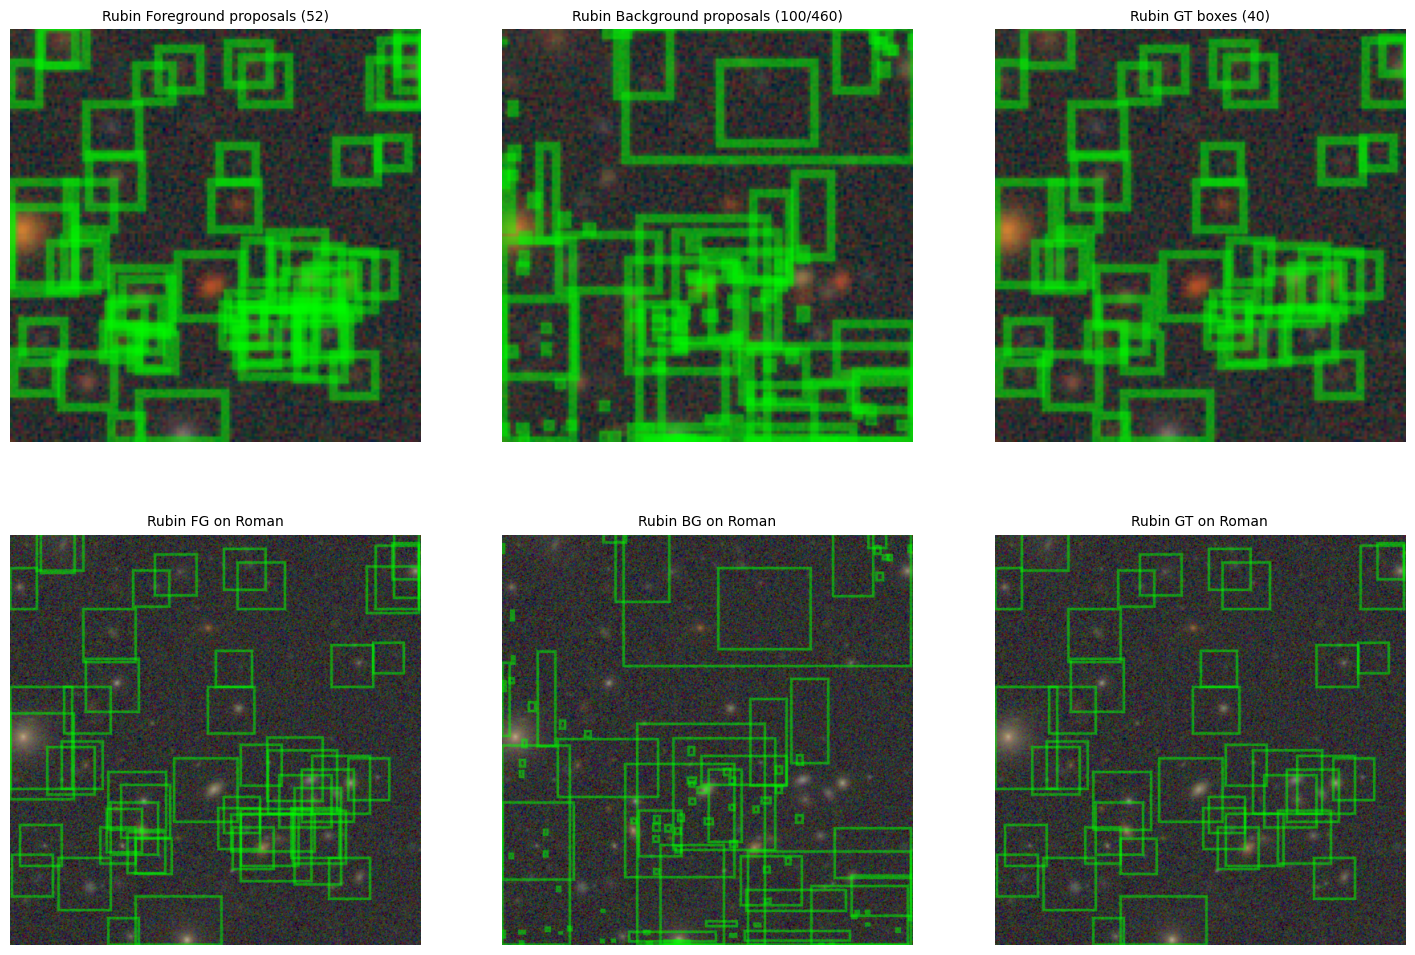

In [13]:
fg_pred = Instances(raw_img.shape[1:], pred_boxes=lp.proposal_boxes[is_fg], pred_classes=lp.gt_classes[is_fg])
bg_classes_vis = torch.zeros_like(lp.gt_classes[is_bg][:100])  # map bg to class 0 for display only
bg_pred = Instances(raw_img.shape[1:], pred_boxes=lp.proposal_boxes[is_bg][:100], pred_classes=bg_classes_vis)
gt_boxes = Instances(raw_img.shape[1:], pred_boxes=gt_inst.gt_boxes, pred_classes=gt_inst.gt_classes)

fg_boxes_roman = scale_boxes(lp.proposal_boxes[is_fg], scale_factor)
bg_boxes_roman = scale_boxes(lp.proposal_boxes[is_bg][:100], scale_factor)
gt_boxes_roman = scale_boxes(gt_inst.gt_boxes, scale_factor)

fg_pred_r = Instances(raw_img_roman.shape[1:], pred_boxes=fg_boxes_roman, pred_classes=lp.gt_classes[is_fg])
bg_classes_vis_r = torch.zeros_like(lp.gt_classes[is_bg][:100])  # map bg to class 0 for display only
bg_pred_r = Instances(raw_img_roman.shape[1:], pred_boxes=bg_boxes_roman, pred_classes=bg_classes_vis_r)
gt_boxes_r = Instances(raw_img_roman.shape[1:], pred_boxes=gt_boxes_roman, pred_classes=gt_inst.gt_classes)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
panels = [
    (fg_pred, ),
    (bg_pred, ),
    (gt_boxes, ),
]

panels = [
    (rgb_img, 1.0, f"Rubin Foreground proposals ({is_fg.sum().item()})", fg_pred),
    (rgb_img, 1.0, f"Rubin Background proposals ({len(lp.proposal_boxes[is_bg][:100])}/{is_bg.sum().item()})", bg_pred),
    (rgb_img, 1.0, f"Rubin GT boxes ({len(gt_inst)})", gt_boxes),
    (rgb_img_roman, 1.0, "Rubin FG on Roman", fg_pred_r),
    (rgb_img_roman, 1.0, "Rubin BG on Roman", bg_pred_r),
    (rgb_img_roman, 1.0, "Rubin GT on Roman", gt_boxes_r),
]

for ax, (img, scale, title, inst) in zip(axes.flatten(), panels):
    v = Visualizer(img.copy(), metadata=astrotest_metadata,
                   scale=scale, instance_mode=ColorMode.SEGMENTATION,
                   enable_color_jitter=False)
    out = v.draw_instance_predictions(inst, alpha=0.5, lf=False,
                                      boxf=True, draw_masks=False)
    ax.imshow(out.get_image(), origin="lower")
    ax.set_title(title, fontsize=10)
    ax.axis("off")

# Forward Contrastive

In [18]:
# Append GT boxes as proposals (so every GT object is guaranteed present),
# then keep only foreground. These are the proposals that enter the
# contrastive loss. After adding gt_objid to the mapper we check
# how many proposals share the same object identity
with torch.no_grad():
    aug_proposals = add_ground_truth_to_proposals(gt_instances, labeled_proposals)
    fg_instances, _ = select_foreground_proposals(aug_proposals, model.roi_heads.num_classes)

for i, inst in enumerate(fg_instances):
    print(f"Image {i}: {len(inst)} foreground proposals entering contrastive loss")
    if inst.has("gt_objid"):
        objids = inst.gt_objid.cpu()
        unique_ids, counts = objids.unique(return_counts=True)
        multi = (counts > 1).sum().item()
        more_than_2 = (counts > 2).sum().item()
        print(f"  {len(unique_ids)} unique objects, "
              f"{multi} with >1 proposal (multi-positive candidates)")
        print(f"  {more_than_2} with >2 proposals (so GT + 2 proposals)")
        print(f"  proposals per object: min={counts.min().item()}, "
              f"max={counts.max().item()}, mean={counts.float().mean().item():.1f}")
    else:
        print("  gt_objid not present so add it to CLIPMapper first")

Image 0: 76 foreground proposals entering contrastive loss
  37 unique objects, 37 with >1 proposal (multi-positive candidates)
  2 with >2 proposals (so GT + 2 proposals)
  proposals per object: min=2, max=3, mean=2.1
Image 1: 69 foreground proposals entering contrastive loss
  32 unique objects, 32 with >1 proposal (multi-positive candidates)
  4 with >2 proposals (so GT + 2 proposals)
  proposals per object: min=2, max=4, mean=2.2
Image 2: 64 foreground proposals entering contrastive loss
  31 unique objects, 31 with >1 proposal (multi-positive candidates)
  2 with >2 proposals (so GT + 2 proposals)
  proposals per object: min=2, max=3, mean=2.1
Image 3: 72 foreground proposals entering contrastive loss
  34 unique objects, 34 with >1 proposal (multi-positive candidates)
  4 with >2 proposals (so GT + 2 proposals)
  proposals per object: min=2, max=3, mean=2.1
Image 4: 65 foreground proposals entering contrastive loss
  32 unique objects, 32 with >1 proposal (multi-positive candidat

Across 16 images:
  GT objects total:                   482 (30.1 per image)
  Foreground proposals total:         539 (33.7 per image)
  Contrastive-loss proposals total (FG + GT):   1021 (63.8 per image)

  Proposals per GT object (contrastive branch):
    min=2, max=4, mean=2.12, median=2.0
    objects with exactly 1 proposal (just the GT box): 0 (0.0%)
    objects with >1 proposal (multi-positive so GT + other proposals): 482 (100.0%)
    objects with >2 proposal (multi-positive): 52 (10.8%)


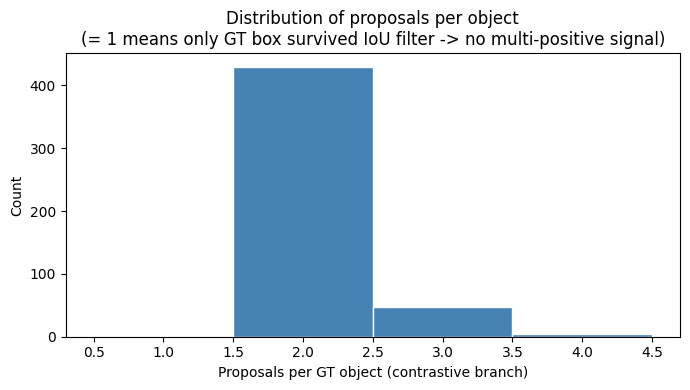

In [19]:
total_gt      = 0
total_fg      = 0
total_cl      = 0
per_obj_counts = []

for gt_inst, lp, fg_inst in zip(gt_instances, labeled_proposals, fg_instances):
    num_classes = model.roi_heads.num_classes
    is_fg = lp.gt_classes < num_classes
    total_gt += len(gt_inst)
    total_fg += is_fg.sum().item()
    total_cl += len(fg_inst)

    if fg_inst.has("gt_objid"):
        _, counts = fg_inst.gt_objid.cpu().unique(return_counts=True)
        per_obj_counts.extend(counts.tolist())

n = len(gt_instances)
print(f"Across {n} images:")
print(f"  GT objects total:                   {total_gt} ({total_gt/n:.1f} per image)")
print(f"  Foreground proposals total:         {total_fg} ({total_fg/n:.1f} per image)")
print(f"  Contrastive-loss proposals total (FG + GT):   {total_cl} ({total_cl/n:.1f} per image)")

if per_obj_counts:
    counts_arr = np.array(per_obj_counts)
    print(f"\n  Proposals per GT object (contrastive branch):")
    print(f"    min={counts_arr.min()}, max={counts_arr.max()}, "
          f"mean={counts_arr.mean():.2f}, median={np.median(counts_arr):.1f}")
    print(f"    objects with exactly 1 proposal (just the GT box): "
          f"{(counts_arr == 1).sum()} ({100*(counts_arr==1).mean():.1f}%)")
    print(f"    objects with >1 proposal (multi-positive so GT + other proposals): "
          f"{(counts_arr > 1).sum()} ({100*(counts_arr>1).mean():.1f}%)")
    print(f"    objects with >2 proposal (multi-positive): "
          f"{(counts_arr > 2).sum()} ({100*(counts_arr>2).mean():.1f}%)")

    plt.figure(figsize=(7, 4))
    plt.hist(counts_arr, bins=range(1, counts_arr.max() + 2),
             align="left", color="steelblue", edgecolor="white")
    plt.xlabel("Proposals per GT object (contrastive branch)")
    plt.ylabel("Count")
    plt.title("Distribution of proposals per object\n"
              "(= 1 means only GT box survived IoU filter -> no multi-positive signal)")
    plt.tight_layout()

# IoU Distribution of Proposals

In our config file, we have set the following values:
```python
model.proposal_generator.nms_thresh = 0.3
for box_predictor in model.roi_heads.box_predictors:
    box_predictor.test_topk_per_image = 2000
    box_predictor.test_score_thresh = 0.5
    box_predictor.test_nms_thresh = 0.3
```
So, all of the proposals that survive into the contrastive branch are guaranteed to have an IoU of at least 0.5. So, the above histogram is a really good sign for motivating a multi-positive InfoNCE loss function instead of our current loss function because before, every object's 1-2 extra proposals were being pushed apart as negatives giving us hundreds of false negatives. Let's still take a look at the IoU distribution of these proposals

In [20]:
# diagonal IoUs across all images
all_ious = []
for inst in fg_instances:    
    if len(inst) == 0:
        continue
    # diagonal: each foreground proposal vs its own matched GT box
    # we know gt will always be at IoU=1.0
    # so we care more abt the distribution of the other proposals
    ious = pairwise_iou(inst.proposal_boxes, inst.gt_boxes).diag()
    all_ious.append(ious.cpu())
    
all_ious = torch.cat(all_ious).numpy()

Total contrastive-branch proposals: 1021
  min=0.501, max=1.000, mean=0.977, median=1.000

Survival rate at each threshold (excluding GT boxes):
  IoU > 0.5: 57/57 = 100.0%
  IoU > 0.6: 21/57 = 36.8%
  IoU > 0.7: 8/57 = 14.0%


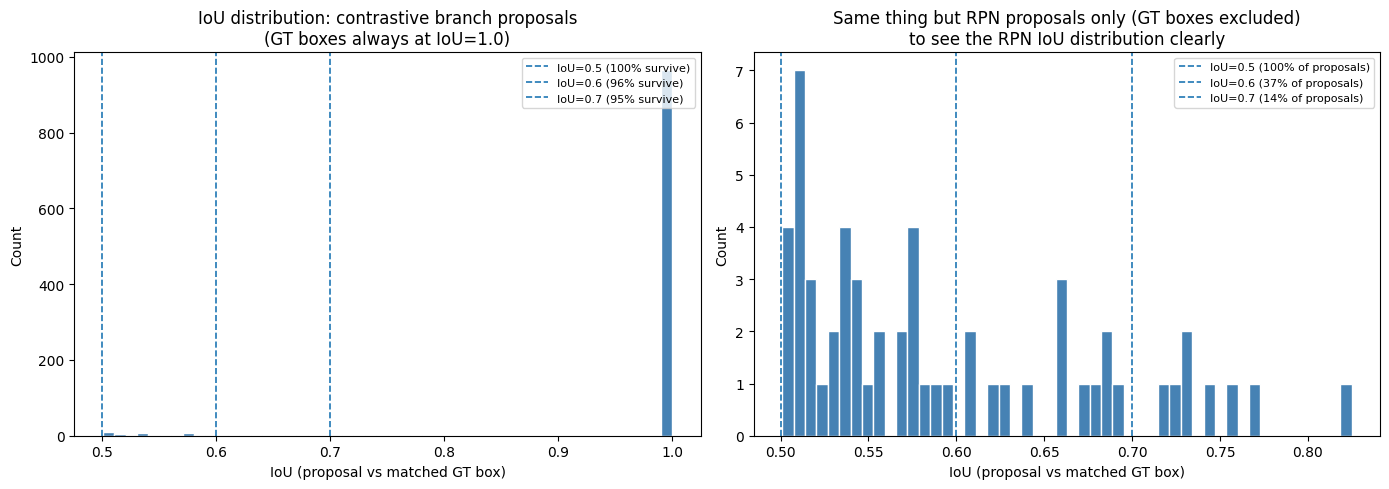

In [21]:
print(f"Total contrastive-branch proposals: {len(all_ious)}")
print(f"  min={all_ious.min():.3f}, max={all_ious.max():.3f}, "
      f"mean={all_ious.mean():.3f}, median={np.median(all_ious):.3f}")

thresholds = [0.5, 0.6, 0.7]
non_gt = all_ious[all_ious < 0.9999]

print("\nSurvival rate at each threshold (excluding GT boxes):")
for t in thresholds:
    surviving = (non_gt > t).sum()
    print(f"  IoU > {t:.1f}: {surviving}/{len(non_gt)} = {100*surviving/len(non_gt):.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: full histogram
axes[0].hist(all_ious, bins=50, color="steelblue", edgecolor="white")
for t in thresholds:
    axes[0].axvline(t, linestyle="--", linewidth=1.2,
                    label=f"IoU={t} ({100*(all_ious>t).mean():.0f}% survive)")
axes[0].set_xlabel("IoU (proposal vs matched GT box)")
axes[0].set_ylabel("Count")
axes[0].set_title("IoU distribution: contrastive branch proposals\n"
                  "(GT boxes always at IoU=1.0)")
axes[0].legend(fontsize=8)

# right: zoom in on [0, 1] excluding the GT-box spike at 1.0
axes[1].hist(non_gt, bins=50, color="steelblue", edgecolor="white")
for t in thresholds:
    axes[1].axvline(t, linestyle="--", linewidth=1.2,
                    label=f"IoU={t} ({100*(non_gt>t).mean():.0f}% of proposals)")
axes[1].set_xlabel("IoU (proposal vs matched GT box)")
axes[1].set_ylabel("Count")
axes[1].set_title("Same thing but RPN proposals only (GT boxes excluded)\n"
                  "to see the RPN IoU distribution clearly")
axes[1].legend(fontsize=8)

plt.tight_layout()